In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("synthetic_5g_kpis.csv")

# 1. Análisis exploratorio:

In [3]:
display(df.head(10))

,time,cell_id,user_id,slice_id,throughput_dl_mbps,throughput_ul_mbps,latency_ms,jitter_ms,packet_loss_pct
0,2025-11-07 10:00:00,cell_01,UE_030,eMBB,62.025775,22.145384,5.838731,0.651401,0.468226
1,2025-11-07 10:00:00,cell_01,UE_016,eMBB,63.844322,13.599499,14.238017,0.823548,0.708354
2,2025-11-07 10:00:00,cell_01,UE_025,eMBB,58.321120,17.440078,11.879174,2.010462,0.470640
3,2025-11-07 10:00:00,cell_01,UE_018,eMBB,40.480508,15.945957,11.630914,1.381730,0.682955
4,2025-11-07 10:00:00,cell_01,UE_009,eMBB,75.772564,20.560936,9.802281,1.323846,0.448923
5,2025-11-07 10:00:00,cell_01,UE_010,eMBB,65.995347,13.271956,14.449947,2.027117,0.680673
6,2025-11-07 10:00:00,cell_01,UE_020,eMBB,84.442490,18.845352,11.884566,1.519720,0.675196
7,2025-11-07 10:00:00,cell_01,UE_026,eMBB,61.548386,21.290894,9.225721,1.757368,0.641635
8,2025-11-07 10:00:00,cell_01,UE_013,eMBB,93.836416,29.300931,15.310983,1.495272,0.782410
9,2025-11-07 10:00:00,cell_01,UE_001,eMBB,89.524731,23.533473,12.924880,2.196021,0.667394


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                21600 non-null  object 
 1   cell_id             21600 non-null  object 
 2   user_id             21600 non-null  object 
 3   slice_id            21600 non-null  object 
 4   throughput_dl_mbps  21600 non-null  float64
 5   throughput_ul_mbps  21600 non-null  float64
 6   latency_ms          21600 non-null  float64
 7   jitter_ms           21600 non-null  float64
 8   packet_loss_pct     21600 non-null  float64
dtypes: float64(5), object(4)
memory usage: 1.5+ MB


None

Tenemos series temporales de:
- time
Momento exacto en el que se tomó la medición (timestamp por minuto).

- site
Nombre del emplazamiento o localización física donde está la estación base.

- cell_id
Identificador de la celda dentro del site (cada estación tiene varias celdas).

- user_id
Identificador del usuario o dispositivo conectado (UE = User Equipment).

- slice_id
Tipo de slice 5G al que pertenece el usuario: eMBB (alta capacidad), URLLC (baja latencia), IoT (bajo consumo).

- rsrp_dbm
Potencia de señal recibida. Mide cuánta señal llega al usuario. Valores más negativos indican peor señal.

- rsrq_db
Calidad de señal recibida. Relaciona señal con interferencia. Más negativo suele significar peor calidad.

- sinr_db
Relación señal/interferencia/ruido. Valores altos indican buena calidad radio.

- throughput_dl_mbps
Velocidad de descarga conseguida por el usuario.

- throughput_ul_mbps
Velocidad de subida conseguida por el usuario.

- latency_ms
Tiempo que tarda un paquete en ir de origen a destino (ms). Importante para URLLC.

- jitter_ms
Variación entre los tiempos de llegada de paquetes. Afecta a aplicaciones tiempo real.

- packet_loss_pct
Porcentaje de paquetes perdidos. A mayor pérdida, peor rendimiento.

- prb_utilization_pct
Porcentaje de uso de recursos de radio (PRB). Indica carga de la celda.

- ho_success_rate
Porcentaje de éxito en handovers entre celdas. Importante para movilidad.

- energy_watts
Consumo energético estimado de la celda en ese instante.

- alarm_rate
Frecuencia o probabilidad de alarmas asociadas al estado de la celda.

## 1.1. Análisis de distribuciones de las variables categóricas:

In [6]:
# Seleccionar columnas categóricas
cat_cols = ["cell_id", "user_id", "slice_id"]

# Mostrar número de categorías y distribución
for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())
    print("\nProporciones:")
    print(df[col].value_counts(normalize=True) * 100)


=== CELL_ID ===
cell_id
cell_01    7200
cell_02    7200
cell_03    7200
Name: count, dtype: int64

Proporciones:
cell_id
cell_01    33.333333
cell_02    33.333333
cell_03    33.333333
Name: proportion, dtype: float64

=== USER_ID ===
user_id
UE_017    758
UE_026    757
UE_008    752
UE_019    751
UE_002    747
UE_003    741
UE_014    737
UE_018    737
UE_001    734
UE_004    733
UE_005    732
UE_025    726
UE_021    721
UE_015    720
UE_010    719
UE_012    718
UE_029    718
UE_027    713
UE_007    711
UE_020    711
UE_006    711
UE_009    708
UE_022    707
UE_024    701
UE_023    696
UE_013    696
UE_028    694
UE_016    691
UE_011    691
UE_030    669
Name: count, dtype: int64

Proporciones:
user_id
UE_017    3.509259
UE_026    3.504630
UE_008    3.481481
UE_019    3.476852
UE_002    3.458333
UE_003    3.430556
UE_014    3.412037
UE_018    3.412037
UE_001    3.398148
UE_004    3.393519
UE_005    3.388889
UE_025    3.361111
UE_021    3.337963
UE_015    3.333333
UE_010    3.328704
UE_

## 1.2. Análisis de las series temporales:

Como tenemos demasiados datos cada muy poco tiempo, hay que agrupar las mediciones cada 5 minutos, para poder ver la señal.

C:\Users\User\AppData\Local\Temp\ipykernel_30340\2281565401.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_agg = df.groupby(df["time"].dt.floor('5T'))[numeric_cols].mean().reset_index()


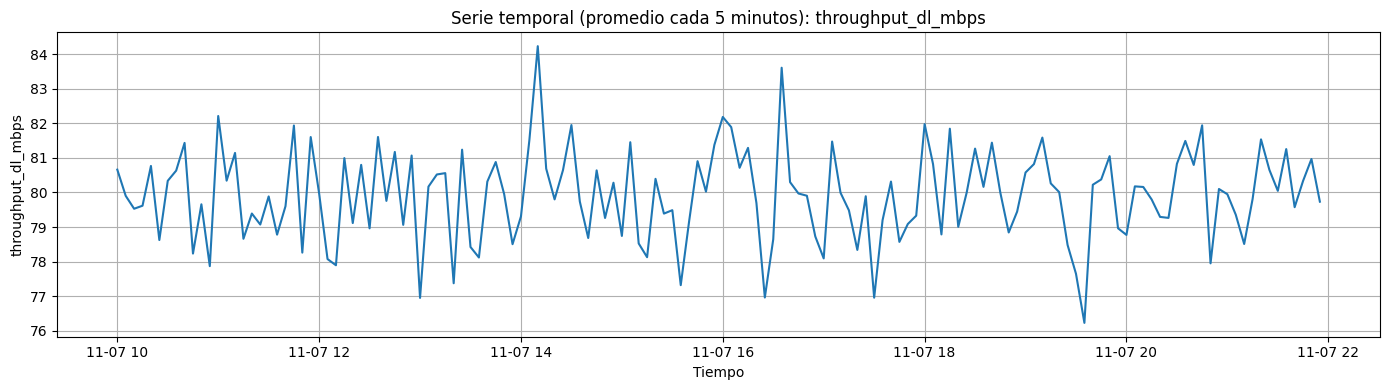

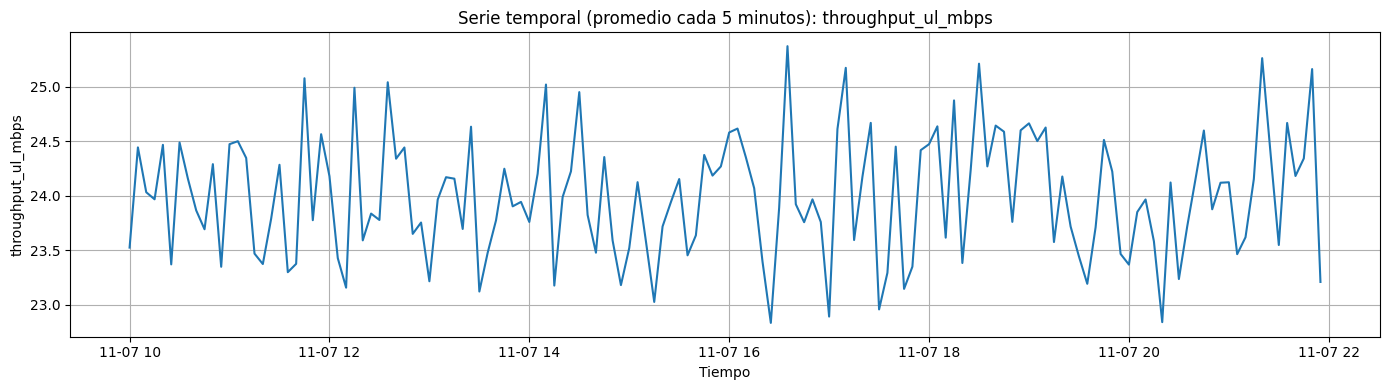

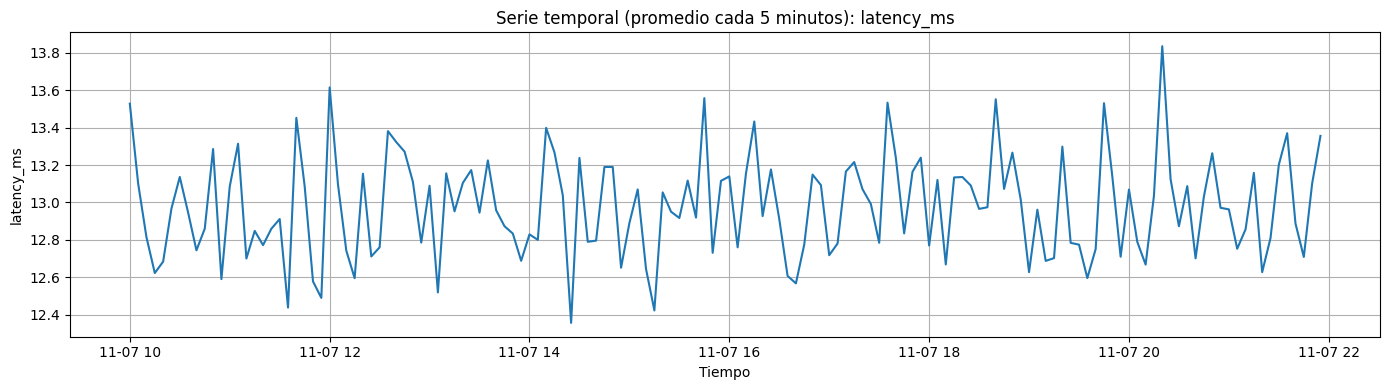

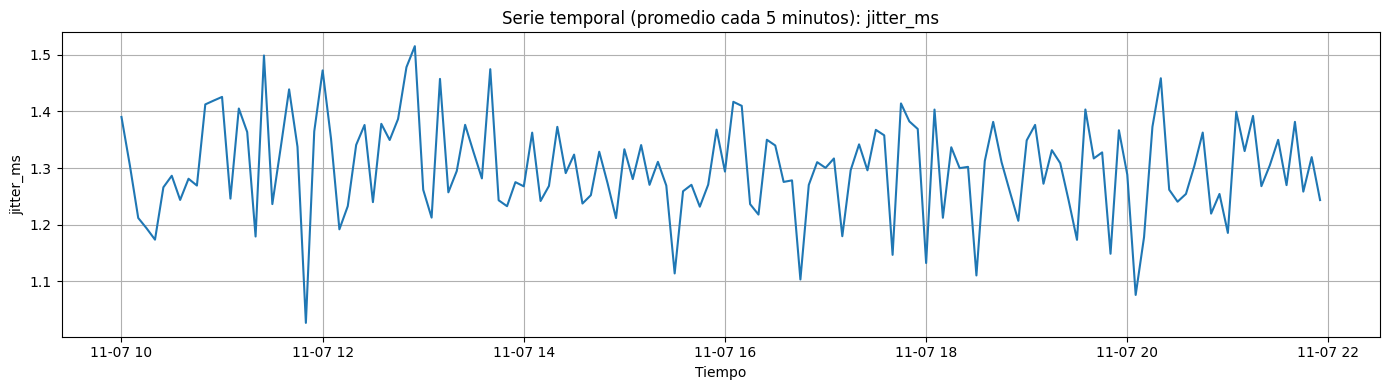

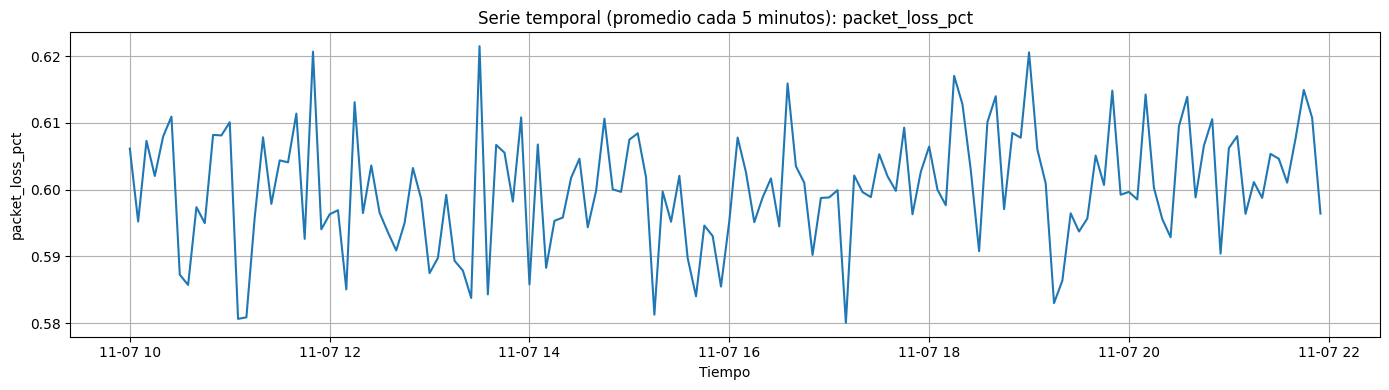

In [7]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Agrupar cada 5 minutos
df_agg = df.groupby(df["time"].dt.floor('5T'))[numeric_cols].mean().reset_index()
df_agg = df_agg.rename(columns={"time": "time"})

# Graficar
for col in numeric_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(df_agg["time"], df_agg[col])
    plt.title(f"Serie temporal (promedio cada 5 minutos): {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Voy a descomponer las gráficas para ver sus características, para ello hay que sacar las frecuencias de cada una:

In [8]:
# Función para el cálculo de frecuencia y periodo dominante
def fft_analysis(signal):
    # Linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1) # Ajuste recta
    trend = np.arange(len(signal)) * slope + intercept #tendencia lineal para cada punto
    detrended = signal - trend # Eliminación de la tendencia lineal  componentes dominantes
    fft_values = np.fft.fft(detrended) # frecuencias correspondientes a cada componente en la FFT
    frequencies = np.fft.fftfreq(len(fft_values)) #Valores de las frecuencias
    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0] #Intensidad de las comp. freq
    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)] #Indice freq.dom
    print(f"Dominant Frequency: {dominant_frequency:.3f}")
    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")
    return dominant_period, positive_frequencies, magnitudes

In [9]:
def seas_decomp_plots(original, decomposition):
    _, axes = plt.subplots(4, 1, sharex=True, sharey=False, figsize=(7, 5))
    axes[0].plot(original, label='Original')
    axes[0].legend(loc='upper left')
    axes[1].plot(decomposition.trend, label='Trend')
    axes[1].legend(loc='upper left')
    axes[2].plot(decomposition.seasonal, label='Seasonality')
    axes[2].legend(loc='upper left')
    axes[3].plot(decomposition.resid, label='Residuals')
    axes[3].legend(loc='upper left')
    plt.show()

throughput_dl_mbps
Dominant Frequency: 0.479
Dominant Period: 2.09 time units


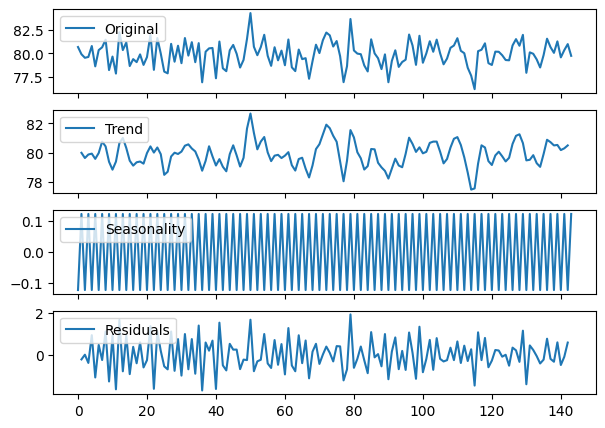

throughput_ul_mbps
Dominant Frequency: 0.306
Dominant Period: 3.27 time units


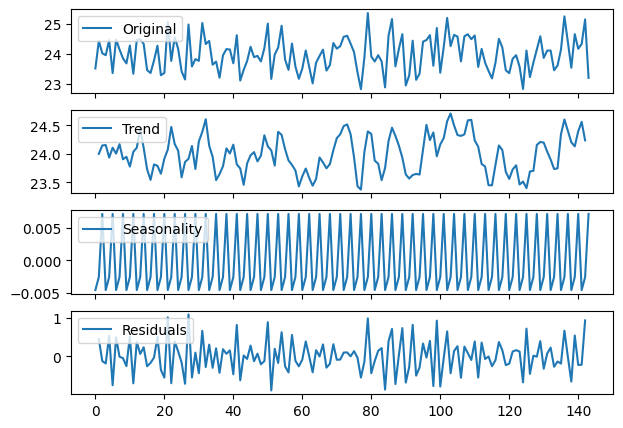

latency_ms
Dominant Frequency: 0.271
Dominant Period: 3.69 time units


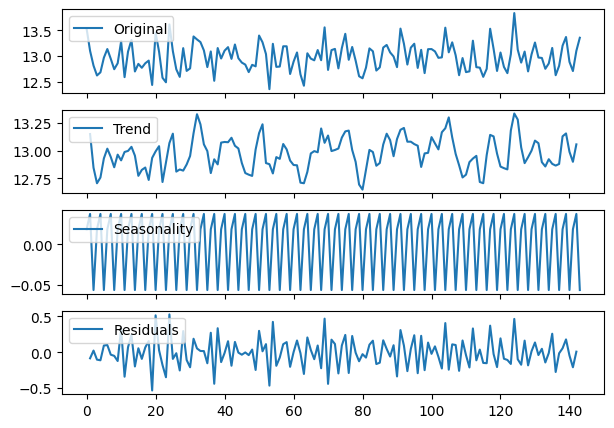

jitter_ms
Dominant Frequency: 0.201
Dominant Period: 4.97 time units


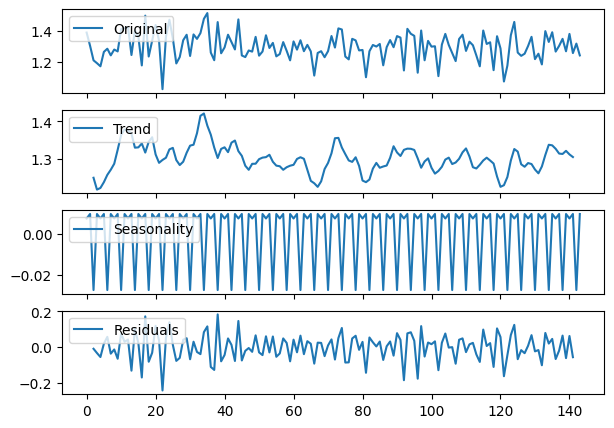

packet_loss_pct
Dominant Frequency: 0.264
Dominant Period: 3.79 time units


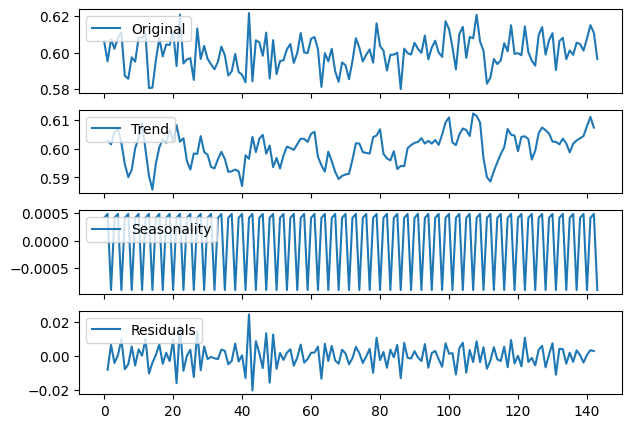

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
for col in numeric_cols:
    print(f'{col}')
    dominant_period,_,_=fft_analysis(df_agg[col])
    additive_decomposition = seasonal_decompose(x=df_agg[col], model='additive', period=int(dominant_period))
    seas_decomp_plots(df_agg[col], additive_decomposition)